In [11]:
import numpy as np
import pandas as pd

In [12]:
df = pd.read_csv('50_Startups_dataset.csv')[['R&D Spend', 'Administration','Marketing Spend', 'Profit']]

In [13]:
df.sample(5)

,R&D Spend,Administration,Marketing Spend,Profit
13,91992.49,135495.17,252665.03,134307.45
14,119943.34,156547.52,256513.02,132602.75
27,72107.70,127864.65,353183.91,105008.41
29,65605.58,153032.16,107138.48,101004.74
5,131877.00,99814.81,362861.46,156991.22


In [14]:
new_df = df.sample(3)

In [15]:
new_df

,R&D Spend,Administration,Marketing Spend,Profit
29,65605.58,153032.16,107138.48,101004.74
27,72107.70,127864.65,353183.91,105008.41
6,134615.56,147198.97,127716.92,156122.61


In [16]:
new_df.rename(columns={'R&D Spend' : 'rnd', 'Administration' : 'adm', 'Marketing Spend' : 'marketing'}, inplace=True)

In [17]:
new_df

,rnd,adm,marketing,Profit
29,65605.58,153032.16,107138.48,101004.74
27,72107.70,127864.65,353183.91,105008.41
6,134615.56,147198.97,127716.92,156122.61


### F0(x) : mean of output column

In [19]:
new_df['f0(x)'] = new_df['Profit'].mean()
new_df

,rnd,adm,marketing,Profit,f0(x)
29,65605.58,153032.16,107138.48,101004.74,120711.92
27,72107.70,127864.65,353183.91,105008.41,120711.92
6,134615.56,147198.97,127716.92,156122.61,120711.92


### Residual of 1st decision Tree

In [20]:
# this should be in loop for all the number of decision trees
new_df['ri1'] = new_df['Profit'] - new_df['f0(x)']
new_df

,rnd,adm,marketing,Profit,f0(x),ri1
29,65605.58,153032.16,107138.48,101004.74,120711.92,-19707.18
27,72107.70,127864.65,353183.91,105008.41,120711.92,-15703.51
6,134615.56,147198.97,127716.92,156122.61,120711.92,35410.69


### Fit Regression trees with inputs and rim

In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

In [26]:
dt1 = DecisionTreeRegressor(max_depth=1)

In [27]:
dt1.fit(new_df.iloc[:,0:3].values, new_df['ri1'].values)

DecisionTreeRegressor(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 103361.633\nsquared_error = 629630045.383\nsamples = 3\nvalue = 0.0'),
 Text(0.25, 0.25, 'squared_error = 4007343.367\nsamples = 2\nvalue = -17705.345'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 0.0\nsamples = 1\nvalue = 35410.69'),
 Text(0.625, 0.5, '  False')]

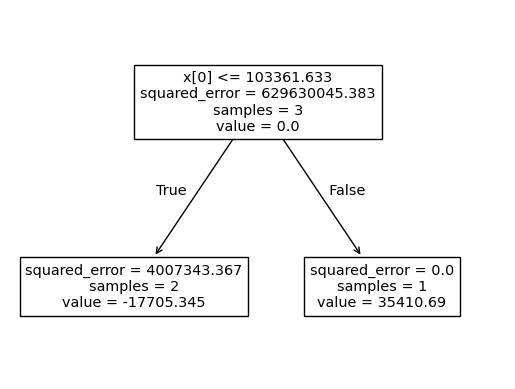

In [28]:
plot_tree(dt1)